# Config A — Tabular RL (Q-Learning & SARSA)

Discrete state space: 716 states × 25 actions.  
Algorithms: Q-Learning, SARSA.

In [1]:
import sys, os
# Ensure project root is importable regardless of how this notebook was launched
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
os.chdir(project_root)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from envs.env_setup import make_sepsis_env, N_STATES, N_ACTIONS
from agents.config_a.q_learning import QLearningAgent, QLearningConfig
from agents.config_a.sarsa import SARSAAgent, SARSAConfig
from utils.evaluation import eval_agent, print_results
from utils.plotting import plot_training_curve, plot_comparison

SEED = 42
np.random.seed(SEED)
print(f'States: {N_STATES}, Actions: {N_ACTIONS}')

States: 716, Actions: 25


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 1. Random Baseline

In [7]:
env = make_sepsis_env()
random_policy = lambda obs: env.action_space.sample()
random_results = eval_agent(random_policy, make_sepsis_env)
print_results('Random Baseline (Config A)', random_results)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== Random Baseline (Config A) ===
  Mean return  : 0.6484 ± 0.4360
  Survival rate: 75.2%
  Mean ep len  : 10.3


## 2. Q-Learning

In [ ]:
# TODO: tune hyperparameters
cfg_ql = QLearningConfig(
    alpha=0.1,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=50_000,
    n_episodes=10_000,
)
ql_agent = QLearningAgent(N_STATES, N_ACTIONS, cfg_ql)

# TODO: implement and call training loop
# ql_returns = ql_agent.train(make_sepsis_env)

In [ ]:
# TODO: evaluate and visualise
# ql_results = eval_agent(ql_agent.get_policy(), make_sepsis_env)
# print_results('Q-Learning (Config A)', ql_results)
# plot_training_curve(ql_returns, label='Q-Learning', save_path='plots/configA_qlearning_curve.png')

## 3. SARSA

In [35]:
# TODO: tune hyperparameters
cfg_sarsa = SARSAConfig(
    alpha=0.05,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=70000,
    n_episodes=10000,
    
)
sarsa_agent = SARSAAgent(N_STATES, N_ACTIONS, cfg_sarsa)

# TODO: implement and call training loop
sarsa_returns = sarsa_agent.train(make_sepsis_env)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


In [41]:
# TODO: tune hyperparameters
cfg_sarsa = SARSAConfig(
    alpha=0.05,           # Start higher so the agent can make big updates early on
    gamma=0.99,           # Reduces variance from late-game patient states
    epsilon_start=1.0,    # 100% random exploration at the beginning
    epsilon_end=0.00,     # CRITICAL: Drop exploration to exactly 0.00 for true exploitation convergence
    epsilon_decay=4000,   # Aggressive Quick-Decay: finishes core exploration by episode 4,000
    n_episodes=10000,
    
)
sarsa_agent = SARSAAgent(N_STATES, N_ACTIONS, cfg_sarsa)

# TODO: implement and call training loop
sarsa_returns = sarsa_agent.train(make_sepsis_env)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


In [42]:
# TODO: evaluate and visualise
sarsa_results = eval_agent(sarsa_agent.get_policy(), make_sepsis_env)
print_results('SARSA (Config A)', sarsa_results)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== SARSA (Config A) ===
  Mean return  : 0.7114 ± 0.4394
  Survival rate: 73.7%
  Mean ep len  : 10.5


<Axes: xlabel='Episode', ylabel='Return'>

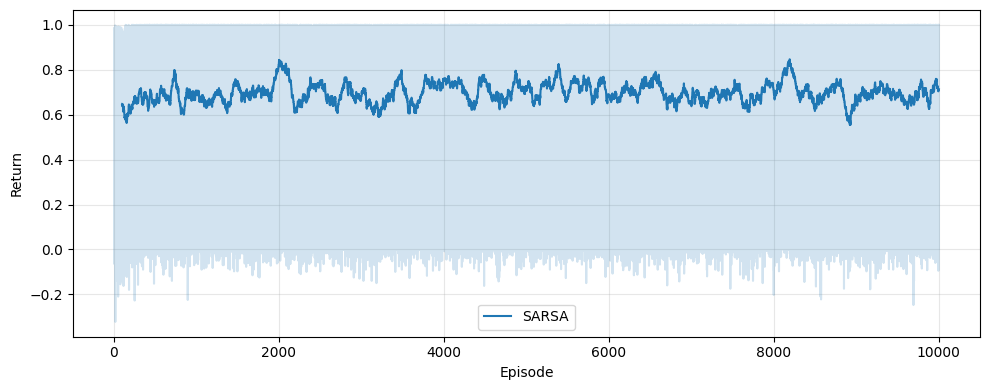

In [43]:
# Plot the training progression
plot_training_curve(sarsa_returns, label='SARSA', save_path='plots/configA_sarsa_curve_test.png')

=== Starting SARSA Grid Search ===

Training: SARSA (α=0.01, decay=30000)
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
-> Survival Rate: 72.2%

Training: SARSA (α=0.01, decay=50000)
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
-> Survival Rate: 73.2%

Training: SARSA (α=0.01, decay=70000)
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
-> Survival Rate: 75.0%

Training: SARSA (α=0.05, decay=30000)
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_

<Axes: title={'center': 'SARSA Hyperparameter Grid Search - Survival Rate'}, ylabel='Survival Rate'>

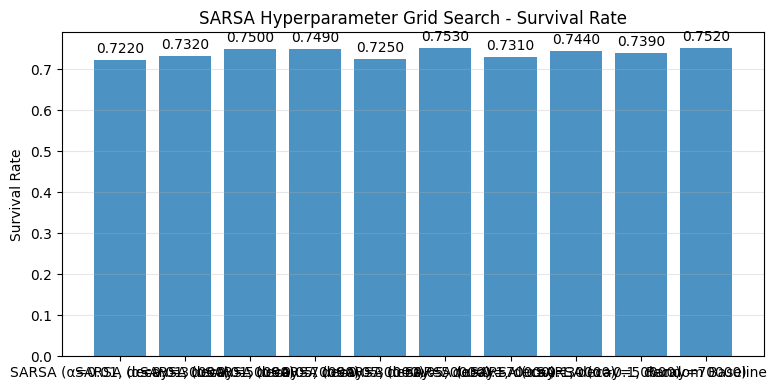

In [14]:
import itertools

# Define the hyperparameter grid
alphas = [0.01, 0.05, 0.1]
epsilon_decays = [30000, 50000, 70000]

grid_results = {}
best_survival_rate = -1.0
best_cfg = None
best_agent = None

print("=== Starting SARSA Grid Search ===")

# Iterate through all combinations
for alpha, decay in itertools.product(alphas, epsilon_decays):
    run_label = f"SARSA (α={alpha}, decay={decay})"
    print(f"\nTraining: {run_label}")
    
    # 1. Initialize configuration with grid parameters
    cfg_grid = SARSAConfig(
        alpha=alpha,
        gamma=1.0,
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay=decay,
        n_episodes=10000,
    )
    
    # 2. Instantiate and train the agent
    agent = SARSAAgent(N_STATES, N_ACTIONS, cfg_grid)
    _ = agent.train(make_sepsis_env)
    
    # 3. Evaluate the trained policy
    results = eval_agent(agent.get_policy(), make_sepsis_env)
    grid_results[run_label] = results
    
    # Track the best performing configuration based on survival rate
    # Handles dictionary or object/namedtuple return formats securely
    current_survival = results.get('survival_rate') if isinstance(results, dict) else getattr(results, 'survival_rate', 0.0)
    
    print(f"-> Survival Rate: {current_survival * 100:.1f}%")
    
    if current_survival > best_survival_rate:
        best_survival_rate = current_survival
        best_cfg = (alpha, decay)
        best_agent = agent

print("\n=== Grid Search Complete ===")
print(f"Best Configuration: α={best_cfg[0]}, epsilon_decay={best_cfg[1]}")
print(f"Best Survival Rate: {best_survival_rate * 100:.1f}%")

# 4. Optional: Include your baseline and visualize the top configurations
# Add your baseline to the dict to see them side by side
if 'random_results' in globals():
    grid_results['Random Baseline'] = random_results

# Plot comparison using your built-in plotting helper
plot_comparison(
    grid_results, 
    metric='survival_rate', 
    title='SARSA Hyperparameter Grid Search - Survival Rate',
    save_path='plots/configA_sarsa_grid_comparison.png'
)

In [ ]:
# 1. Define an aggressive, wide-reaching hyperparameter grid
alphas = [0.02, 0.05, 0.1]
epsilon_decays = [4000, 6000, 8000] # Faster decays to maximize exploitation time
gammas = [0.99, 1.0]
alpha_decays = ['constant', 'linear']
q_initializations = [0.0, 1.0]       # 0.0 vs Optimistic Initial Values

best_survival_rate = 0.0
best_params = {}

print("=== Starting Advanced Multi-Parameter Grid Search ===")

# Generate all parameter combinations
grid = itertools.product(alphas, epsilon_decays, gammas, alpha_decays, q_initializations)

for alpha, decay, gamma, a_decay_type, q_init in grid:
    
    # Configure the parameters
    cfg_grid = SARSAConfig(
        alpha=alpha,
        gamma=gamma,
        epsilon_start=1.0,
        epsilon_end=0.01, # Lower end exploration to 1% to maximize pure testing
        epsilon_decay=decay,
        n_episodes=10000,
    )
    
    # Initialize the agent
    agent = SARSAAgent(N_STATES, N_ACTIONS, cfg_grid)
    
    # [CRITICAL FIX] Apply Optimistic Initialization if requested
    if q_init > 0.0:
        agent.Q = np.full((N_STATES, N_ACTIONS), q_init, dtype=float)
        
    # CUSTOM TRAINING LOOP (Injecting Learning Rate Decay if selected)
    env = make_sepsis_env()
    epsilon = cfg_grid.epsilon_start
    current_alpha = alpha
    
    for episode in range(cfg_grid.n_episodes):
        state, info = env.reset()
        
        # Action Selection with Greedy Tie-Breaking
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            # Break max ties randomly to bypass action '0' structural bias
            max_actions = np.where(agent.Q[state] == np.max(agent.Q[state]))[0]
            action = np.random.choice(max_actions)
            
        terminated = False
        truncated = False
        
        while not (terminated or truncated):
            next_state, reward, terminated, truncated, info = env.step(action)
            
            if np.random.rand() < epsilon:
                next_action = env.action_space.sample()
            else:
                max_next_actions = np.where(agent.Q[next_state] == np.max(agent.Q[next_state]))[0]
                next_action = np.random.choice(max_next_actions)
                
            # SARSA target assignment
            if terminated:
                target = reward
            else:
                target = reward + gamma * agent.Q[next_state, next_action]
                
            # Q-update using modulated Alpha
            agent.Q[state, action] += current_alpha * (target - agent.Q[state, action])
            
            state = next_state
            action = next_action
            
        # Decay Epsilon
        epsilon = max(cfg_grid.epsilon_end, epsilon - (1.0 - cfg_grid.epsilon_end) / cfg_grid.epsilon_decay)
        
        # Decay Alpha if specified
        if a_decay_type == 'linear':
            current_alpha = max(0.005, alpha * (1.0 - (episode / cfg_grid.n_episodes)))

    # 2. Evaluation phase using greedy selection
    results = eval_agent(agent.get_policy(), make_sepsis_env)
    current_survival = results.get('survival_rate') if isinstance(results, dict) else getattr(results, 'survival_rate', 0.0)
    
    # 3. Print out tracking progress
    if current_survival > best_survival_rate:
        best_survival_rate = current_survival
        best_params = {
            'alpha': alpha, 'decay': decay, 'gamma': gamma, 
            'alpha_decay': a_decay_type, 'q_init': q_init
        }
        print(f"-> NEW BEST: Survival = {current_survival*100:.2f}% | α={alpha}, Decay={decay}, γ={gamma}, α-Decay={a_decay_type}, Q0={q_init}")
        

print("\n=== Grid Search Complete ===")
print("Best Hyperparameters Found:", best_params)
print(f"Max Achieved Survival Rate: {best_survival_rate*100:.2f}%")

=== Starting Advanced Multi-Parameter Grid Search ===
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
-> NEW BEST: Survival = 74.20% | α=0.02, Decay=4000, γ=0.99, α-Decay=constant, Q0=0.0
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
-> NEW BEST: Survival = 75.50% | α=0.02, Decay=4000, γ=0.99, α-Decay=constant, Q0=1.0
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make

## 4. Comparison

In [ ]:
# TODO: uncomment after training both agents
# all_results = {
#     'Random': random_results,
#     'Q-Learning': ql_results,
#     'SARSA': sarsa_results,
# }
# plot_comparison(all_results, metric='survival_rate', title='Config A — Survival Rate',
#                 save_path='plots/configA_comparison.png')